In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
plt.rcParams['figure.figsize'] = (14, 5)

DATA_DIR    = '../data/raw/clusterdata2018/'
FIGURES_DIR = '../results/figures/'
METRICS_DIR = '../results/metrics/'

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)

print('Paths OK')
print('Data    :', os.path.abspath(DATA_DIR))
print('Figures :', os.path.abspath(FIGURES_DIR))
print('Metrics :', os.path.abspath(METRICS_DIR))

Paths OK
Data    : /Users/prarthanagovindaraj/Desktop/Cloud_Resource_Optimisation_thesis/data/raw/clusterdata2018
Figures : /Users/prarthanagovindaraj/Desktop/Cloud_Resource_Optimisation_thesis/results/figures
Metrics : /Users/prarthanagovindaraj/Desktop/Cloud_Resource_Optimisation_thesis/results/metrics


In [3]:
def explore_csv_file(file_path):
    try:
        # Try different parsing strategies
        parsing_strategies = [
            {'sep': ',', 'header': 'infer'},  # Standard CSV with headers
            {'sep': ',', 'header': None},     # CSV without headers
            {'sep': '\t', 'header': 'infer'}, # Tab-separated with headers
            {'sep': '\t', 'header': None}     # Tab-separated without headers
        ]
        
        for strategy in parsing_strategies:
            try:
                # Attempt to read file with current strategy
                df = pd.read_csv(file_path, **strategy)
                
                # Basic validation
                if not df.empty:
                    return df
            except Exception as e:
                print(f"Failed with strategy {strategy}: {e}")
        
        print(f"Could not load file: {file_path}")
        return None
    except Exception as e:
        print(f"Unexpected error loading {file_path}: {e}")
        return None

In [4]:
def analyze_dataset_columns(df, dataset_name):
    print(f"\n{'='*50}")
    print(f"Dataset: {dataset_name}")
    print(f"{'='*50}")
    
    # Basic dataset information
    print(f"Total Rows: {len(df)}")
    print(f"Total Columns: {len(df.columns)}")
    
    # Column analysis
    print("\nColumn Analysis:")
    for col in df.columns:
        try:
            # Basic column statistics
            print(f"\nColumn: {col}")
            print(f"Data Type: {df[col].dtype}")
            
            # Unique values
            unique_count = df[col].nunique()
            print(f"Unique Values: {unique_count}")
            
            # Sample values
            print("Sample Values:")
            # For numeric columns, show some basic stats
            if pd.api.types.is_numeric_dtype(df[col]):
                print(f"  Min: {df[col].min()}")
                print(f"  Max: {df[col].max()}")
                print(f"  Mean: {df[col].mean():.4f}")
            else:
                # For non-numeric, show a few unique values
                print("  " + ", ".join(map(str, df[col].dropna().unique()[:5])))
        
        except Exception as e:
            print(f"  Error analyzing column {col}: {e}")

In [5]:
# Load and analyze Batch Task Dataset
batch_task_path = '../data/raw/clusterdata2018/batch_task.csv'
batch_task_df = explore_csv_file(batch_task_path)

if batch_task_df is not None:
    analyze_dataset_columns(batch_task_df, 'Batch Task Dataset')
    
    # Display first few rows
    print("\nFirst few rows:")
    print(batch_task_df.head())


Dataset: Batch Task Dataset
Total Rows: 80552
Total Columns: 8

Column Analysis:

Column: 6459
Data Type: int64
Unique Values: 12073
Sample Values:
  Min: -1078
  Max: 60181
  Mean: 34015.5595

Column: 6524
Data Type: int64
Unique Values: 33482
Sample Values:
  Min: -843
  Max: 61668
  Mean: 34102.9910

Column: 3
Data Type: int64
Unique Values: 12951
Sample Values:
  Min: 1
  Max: 12951
  Mean: 6510.7179

Column: 4
Data Type: int64
Unique Values: 80552
Sample Values:
  Min: 1
  Max: 80553
  Mean: 40277.5000

Column: 15740
Data Type: int64
Unique Values: 1664
Sample Values:
  Min: 1
  Max: 64486
  Mean: 147.6510

Column: Terminated
Data Type: str
Unique Values: 4
Sample Values:
  Terminated, Waiting, Running, Failed

Column: 50
Data Type: float64
Unique Values: 13
Sample Values:
  Min: 40.0
  Max: 800.0
  Mean: 62.5004

Column: 0.007956928014909534
Data Type: float64
Unique Values: 749
Sample Values:
  Min: 0.0027541221235731
  Max: 0.1273315559236922
  Mean: 0.0072

First few rows:
  

In [6]:
# Load and analyze Container Usage Dataset
container_usage_path = '../data/raw/clusterdata2018/container_usage.csv'
container_usage_df = explore_csv_file(container_usage_path)

if container_usage_df is not None:
    analyze_dataset_columns(container_usage_df, 'Container Usage Dataset')
    
    # Display first few rows
    print("\nFirst few rows:")
    print(container_usage_df.head())
    


Dataset: Container Usage Dataset
Total Rows: 1480905
Total Columns: 12

Column Analysis:

Column: 42900
Data Type: int64
Unique Values: 144
Sample Values:
  Min: 39600
  Max: 82500
  Mean: 61110.5369

Column: 106
Data Type: int64
Unique Values: 10359
Sample Values:
  Min: 1
  Max: 11275
  Mean: 5638.7622

Column: 42.840000152599686
Data Type: float64
Unique Values: 1001756
Sample Values:
  Min: 0.3000000044700026
  Max: 98.9199996948184
  Mean: 9.5026

Column: 65.5199996948184
Data Type: float64
Unique Values: 574811
Sample Values:
  Min: 0.5
  Max: 78.24999809262772
  Mean: 44.2978

Column: 17.139999771119943
Data Type: float64
Unique Values: 251044
Sample Values:
  Min: 1.0
  Max: 100.0
  Mean: 14.3462

Column: 3.1400000095379834
Data Type: float64
Unique Values: 325747
Sample Values:
  Min: 0.0
  Max: 58.14000015257838
  Mean: 0.8350

Column: 3.400000000001965
Data Type: float64
Unique Values: 157183
Sample Values:
  Min: 0.0
  Max: 56.16000061035861
  Mean: 0.8329

Column: 3.65999

In [7]:
# Load and analyze Server Usage Dataset
server_usage_path = '../data/raw/clusterdata2018/server_usage.csv'
server_usage_df = explore_csv_file(server_usage_path)

if server_usage_df is not None:
    analyze_dataset_columns(server_usage_df, 'Server Usage Dataset')
    
    # Display first few rows
    print("\nFirst few rows:")
    print(server_usage_df.head())


Dataset: Server Usage Dataset
Total Rows: 187962
Total Columns: 8

Column Analysis:

Column: 41700
Data Type: int64
Unique Values: 144
Sample Values:
  Min: 39600
  Max: 82500
  Mean: 61082.0474

Column: 237
Data Type: int64
Unique Values: 1310
Sample Values:
  Min: 1
  Max: 1313
  Mean: 657.1792

Column: 23.3799999237
Data Type: float64
Unique Values: 38813
Sample Values:
  Min: 0.5
  Max: 89.71999969482
  Mean: 26.4678

Column: 30.08000030518
Data Type: float64
Unique Values: 33827
Sample Values:
  Min: 2.29999995232
  Max: 95.42000122072
  Mean: 48.9459

Column: 42.2000007629
Data Type: float64
Unique Values: 7725
Sample Values:
  Min: 27.3999996185
  Max: 96.81999969482
  Mean: 47.0776

Column: 15.820000267020001
Data Type: float64
Unique Values: 38446
Sample Values:
  Min: 0.0
  Max: 132.07999725320002
  Mean: 18.4689

Column: 13.860000038159999
Data Type: float64
Unique Values: 34465
Sample Values:
  Min: 0.0
  Max: 128.6
  Mean: 18.0845

Column: 12.64000015258
Data Type: float6

In [8]:
# Comparative analysis of datasets
datasets = {
    'Batch Task': batch_task_df,
    'Container Usage': container_usage_df,
    'Server Usage': server_usage_df
}

print("Dataset Comparison:")
for name, df in datasets.items():
    if df is not None:
        print(f"\n{name} Dataset:")
        print(f"Rows: {len(df)}")
        print(f"Columns: {len(df.columns)}")
        print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")

Dataset Comparison:

Batch Task Dataset:
Rows: 80552
Columns: 8
Memory Usage: 9.22 MB

Container Usage Dataset:
Rows: 1480905
Columns: 12
Memory Usage: 142.17 MB

Server Usage Dataset:
Rows: 187962
Columns: 8
Memory Usage: 12.03 MB


In [9]:
# Inspect column names for each dataset
for csv_file in ['batch_task.csv', 'container_usage.csv', 'server_usage.csv']:
    print(f"\n{'='*50}")
    print(f"Columns in {csv_file}:")
    print(f"{'='*50}")
    
    # Full path to the file
    file_path = f'../data/raw/clusterdata2018/{csv_file}'
    
    # Read first few rows to display column names
    df = pd.read_csv(file_path)
    
    # Print column names with their index
    for i, col in enumerate(df.columns):
        print(f"{i}: {col}")


Columns in batch_task.csv:
0: 6459
1: 6524
2: 3
3: 4
4: 15740
5: Terminated
6: 50
7: 0.007956928014909534

Columns in container_usage.csv:
0: 42900
1: 106
2: 42.840000152599686
3: 65.5199996948184
4: 17.139999771119943
5: 3.1400000095379834
6: 3.400000000001965
7: 3.6599999427780987
8: 0.06462796876827408
9: 0.0343371623644167
10: 0.726102411747
11: 0.457575917244

Columns in server_usage.csv:
0: 41700
1: 237
2: 23.3799999237
3: 30.08000030518
4: 42.2000007629
5: 15.820000267020001
6: 13.860000038159999
7: 12.64000015258


In [10]:
# Define column names for each dataset
COLUMN_NAMES = {
    'batch_task.csv': [
        'task_name', 'instance_num', 'job_name', 'task_type', 
        'status', 'start_time', 'end_time', 'plan_cpu', 'plan_mem'
    ],
    'container_usage.csv': [
        'container_id', 'machine_id', 'time_stamp', 
        'cpu_util_percent', 'mem_util_percent', 'cpi', 
        'mem_gps', 'mpki', 'net_in', 'net_out', 'disk_io_percent'
    ]
}

In [11]:
def load_dataset(filename, columns):
    """
    Load dataset with specified column names
    
    Args:
        filename (str): Name of the CSV file
        columns (list): List of column names
    
    Returns:
        pd.DataFrame: Loaded and named DataFrame
    """
    try:
        file_path = f'../data/raw/clusterdata2018/{filename}'
        
        # Load the dataset
        df = pd.read_csv(file_path, header=None, names=columns)
        
        print(f"\n{'='*50}")
        print(f"Dataset: {filename}")
        print(f"{'='*50}")
        
        # Basic information
        print(f"Total Rows: {len(df)}")
        print(f"Total Columns: {len(df.columns)}")
        # Column details
        for col in df.columns:
            print(f"\nColumn: {col}")
            print(f"Data Type: {df[col].dtype}")
            print(f"Unique Values: {df[col].nunique()}")
            
            # Sample statistics for numeric columns
            if pd.api.types.is_numeric_dtype(df[col]):
                print(f"Min: {df[col].min()}")
                print(f"Max: {df[col].max()}")
                print(f"Mean: {df[col].mean():.4f}")
        
        return df
    
    except Exception as e:
        print(f"Error loading {filename}: {e}")
        return None
    # Analyze specified files
files_to_analyze = ['batch_task.csv', 'container_usage.csv']

# Store datasets in a dictionary for further analysis
datasets = {}
for filename in files_to_analyze:
    columns = COLUMN_NAMES.get(filename)
    if columns:
        datasets[filename] = load_dataset(filename, columns)


Dataset: batch_task.csv
Total Rows: 80553
Total Columns: 9

Column: task_name
Data Type: int64
Unique Values: 12073
Min: -1078
Max: 60181
Mean: 34015.2174

Column: instance_num
Data Type: int64
Unique Values: 33483
Min: -843
Max: 61668
Mean: 34102.6486

Column: job_name
Data Type: int64
Unique Values: 12951
Min: 1
Max: 12951
Mean: 6510.6371

Column: task_type
Data Type: int64
Unique Values: 80553
Min: 1
Max: 80553
Mean: 40277.0000

Column: status
Data Type: int64
Unique Values: 1664
Min: 1
Max: 64486
Mean: 147.8445

Column: start_time
Data Type: str
Unique Values: 4

Column: end_time
Data Type: float64
Unique Values: 13
Min: 40.0
Max: 800.0
Mean: 62.5002

Column: plan_cpu
Data Type: float64
Unique Values: 749
Min: 0.0027541221235731
Max: 0.1273315559236922
Mean: 0.0072

Column: plan_mem
Data Type: float64
Unique Values: 0
Min: nan
Max: nan
Mean: nan

Dataset: container_usage.csv
Total Rows: 1480906
Total Columns: 11

Column: container_id
Data Type: int64
Unique Values: 10359
Min: 1
Ma

In [12]:


# Define column names for each dataset based on the schema
COLUMN_NAMES = {
    'batch_task.csv': [
        'task_name', 'instance_num', 'job_name', 'task_type', 
        'status', 'start_time', 'end_time', 'plan_cpu', 'plan_mem'
    ],
    'container_usage.csv': [
        'container_id', 'machine_id', 'time_stamp', 
        'cpu_util_percent', 'mem_util_percent', 'cpi', 
        'mem_gps', 'mpki', 'net_in', 'net_out', 'disk_io_percent'
    ],
    'server_usage.csv': [
        'machine_id', 'time_stamp', 
        'cpu_util_percent', 'mem_util_percent', 'mem_gps', 
        'mkpi', 'net_in', 'net_out', 'disk_io_percent'
    ]
}

def load_and_rename_dataset(filename):
    """
    Load dataset and rename columns based on predefined schema
    """
    try:
        file_path = f'../data/raw/clusterdata2018/{filename}'
        
        # Get column names for this specific file
        columns = COLUMN_NAMES.get(filename)
        
        if not columns:
            print(f"No predefined column names found for {filename}")
            return None
        
        # Read CSV with no header and apply column names
        df = pd.read_csv(file_path, header=None, names=columns)
        
        print(f"\n{'='*50}")
        print(f"Dataset: {filename}")
        print(f"{'='*50}")
        
        # Basic dataset information
        print(f"Total Rows: {len(df)}")
        print(f"Total Columns: {len(df.columns)}")
        
        # Column details with schema-based names
        for col in columns:
            print(f"\nColumn: {col}")
            print(f"Data Type: {df[col].dtype}")
            print(f"Unique Values: {df[col].nunique()}")
            
            # Sample statistics for numeric columns
            if pd.api.types.is_numeric_dtype(df[col]):
                print(f"Min: {df[col].min()}")
                print(f"Max: {df[col].max()}")
                print(f"Mean: {df[col].mean():.4f}")
        
        return df
    
    except Exception as e:
        print(f"Error loading {filename}: {e}")
        return None

# Analyze specified files
files_to_analyze = ['batch_task.csv', 'container_usage.csv', 'server_usage.csv']

# Store datasets in a dictionary for further analysis
datasets = {}
for filename in files_to_analyze:
    datasets[filename] = load_and_rename_dataset(filename)


Dataset: batch_task.csv
Total Rows: 80553
Total Columns: 9

Column: task_name
Data Type: int64
Unique Values: 12073
Min: -1078
Max: 60181
Mean: 34015.2174

Column: instance_num
Data Type: int64
Unique Values: 33483
Min: -843
Max: 61668
Mean: 34102.6486

Column: job_name
Data Type: int64
Unique Values: 12951
Min: 1
Max: 12951
Mean: 6510.6371

Column: task_type
Data Type: int64
Unique Values: 80553
Min: 1
Max: 80553
Mean: 40277.0000

Column: status
Data Type: int64
Unique Values: 1664
Min: 1
Max: 64486
Mean: 147.8445

Column: start_time
Data Type: str
Unique Values: 4

Column: end_time
Data Type: float64
Unique Values: 13
Min: 40.0
Max: 800.0
Mean: 62.5002

Column: plan_cpu
Data Type: float64
Unique Values: 749
Min: 0.0027541221235731
Max: 0.1273315559236922
Mean: 0.0072

Column: plan_mem
Data Type: float64
Unique Values: 0
Min: nan
Max: nan
Mean: nan

Dataset: container_usage.csv
Total Rows: 1480906
Total Columns: 11

Column: container_id
Data Type: int64
Unique Values: 10359
Min: 1
Ma

In [13]:
import pandas as pd

DATA_DIR = '../data/raw/clusterdata2018/'

# 8 columns — task_type is NOT present in this file
cols_batch_task = [
    'task_name',    # col 1
    'instance_num', # col 2
    'job_name',     # col 3
    'task_id',      # col 4
    'start_time',   # col 5
    'status',       # col 6 — Terminated / Waiting
    'plan_cpu',     # col 7 — REQUESTED CPU (100 = 1 core)
    'plan_mem'      # col 8 — REQUESTED Memory (normalised)
]

bt = pd.read_csv(DATA_DIR + 'batch_task.csv', 
                 header=None, 
                 names=cols_batch_task)

print(f'Shape: {bt.shape}')
print(f'\nDtypes:\n{bt.dtypes}')
print(f'\nSample rows:')
print(bt.head(5))
print(f'\nStatus counts:\n{bt["status"].value_counts()}')
print(f'\nplan_cpu stats:\n{bt["plan_cpu"].describe()}')

Shape: (80553, 8)

Dtypes:
task_name         int64
instance_num      int64
job_name          int64
task_id           int64
start_time        int64
status              str
plan_cpu        float64
plan_mem        float64
dtype: object

Sample rows:
   task_name  instance_num  job_name  task_id  start_time      status  \
0       6459          6524         3        4       15740  Terminated   
1       6457          6533         3        5           1  Terminated   
2       6036          6046         4        7         393     Waiting   
3       6036          6046         4        6         452     Waiting   
4      10719         11332        15       67        1705  Terminated   

   plan_cpu  plan_mem  
0      50.0  0.007957  
1      50.0  0.004395  
2       NaN       NaN  
3       NaN       NaN  
4      50.0  0.005736  

Status counts:
status
Terminated    67013
Waiting        8847
Running        3567
Failed         1126
Name: count, dtype: int64

plan_cpu stats:
count    71536.000000
me

In [14]:
cols_batch_instance = [
    'instance_name', 'task_name', 'job_name', 'task_type',
    'status', 'start_time', 'end_time', 'machine_id',
    'seq_no', 'total_seq_no',
    'cpu_avg', 'cpu_max', 'mem_avg', 'mem_max'
]

bi = pd.read_csv(DATA_DIR + 'batch_instance.csv',
                 header=None,
                 names=cols_batch_instance)

print(f'Shape: {bi.shape}')
print(bi.head(3))
print(bi[['cpu_avg','cpu_max','mem_avg','mem_max']].describe())

Shape: (16094656, 14)
   instance_name  task_name  job_name  task_type  status  start_time  \
0          41562      41618     120.0      686.0   299.0  Terminated   
1          41561      41619     120.0      686.0  1279.0  Terminated   
2          41562      41617     120.0      686.0   828.0  Terminated   

   end_time  machine_id  seq_no  total_seq_no  cpu_avg  cpu_max  mem_avg  \
0         1           1    1.50          0.29      NaN      NaN      NaN   
1         1           1    0.89          0.28      NaN      NaN      NaN   
2         1           1    0.94          0.29      NaN      NaN      NaN   

   mem_max  
0      NaN  
1      NaN  
2      NaN  
            cpu_avg       cpu_max  mem_avg  mem_max
count  1.927100e+06  1.928332e+06      0.0      0.0
mean   2.234298e-02  1.828878e-02      NaN      NaN
std    1.788767e-02  1.528432e-02      NaN      NaN
min    0.000000e+00  2.484922e-04      NaN      NaN
25%    7.164859e-03  4.923252e-03      NaN      NaN
50%    2.094065e-02 

In [15]:
cols_container_usage = [
    'container_id', 'machine_id', 'time_stamp',
    'cpu_util_percent', 'mem_util_percent', 'cpi',
    'mem_gps', 'mpki', 'net_in', 'net_out', 'disk_io_percent'
]

cu = pd.read_csv(DATA_DIR + 'container_usage.csv',
                 header=None,
                 names=cols_container_usage,
                 nrows=500_000)  # sample — file is huge

print(f'Shape: {cu.shape}')
print(cu.head(3))
print(cu[['cpu_util_percent','mem_util_percent']].describe())

Shape: (500000, 11)
       container_id  machine_id  time_stamp  cpu_util_percent  \
42900           106       42.84       65.52             17.14   
42600           107        3.30       24.00              5.20   
42300           108        3.14       25.60             10.60   

       mem_util_percent   cpi  mem_gps      mpki    net_in   net_out  \
42900              3.14  3.40     3.66  0.064628  0.034337  0.726102   
42600              0.54  0.38     0.30  0.155430  0.550153  2.211467   
42300              0.08  0.14     0.20  0.199342  0.294852  2.633724   

       disk_io_percent  
42900         0.457576  
42600        12.187318  
42300         3.997216  
       cpu_util_percent  mem_util_percent
count     499996.000000     499996.000000
mean          14.178450          0.981044
std            9.704842          1.871315
min            1.400000          0.000000
25%            8.200000          0.220000
50%           11.900000          0.440000
75%           16.799999          0.9

In [16]:
# Check exact number of columns in the raw file
import subprocess
result = subprocess.run(
    ['awk', '-F,', '{print NF; exit}', '../data/raw/clusterdata2018/batch_instance.csv'],
    capture_output=True, text=True
)
print('Number of columns in batch_instance.csv:', result.stdout.strip())

# Also peek at first 2 raw rows
bi_raw = pd.read_csv(DATA_DIR + 'batch_instance.csv', header=None, nrows=3)
print(bi_raw)
print('Column count:', len(bi_raw.columns))

Number of columns in batch_instance.csv: 12
      0      1    2    3     4           5   6   7     8     9   10  11
0  41562  41618  120  686   299  Terminated   1   1  1.50  0.29 NaN NaN
1  41561  41619  120  686  1279  Terminated   1   1  0.89  0.28 NaN NaN
2  41562  41617  120  686   828  Terminated   1   1  0.94  0.29 NaN NaN
Column count: 12


In [17]:
#column mapping
cols_batch_instance = [
    'instance_name',  # col 0
    'task_name',      # col 1
    'job_name',       # col 2
    'task_id',        # col 3
    'start_time',     # col 4
    'status',         # col 5 — Terminated / Waiting
    'end_time',       # col 6
    'machine_id',     # col 7
    'cpu_avg',        # col 8  ★ actual avg CPU used
    'cpu_max',        # col 9  ★ actual peak CPU used
    'mem_avg',        # col 10 — NaN in this dataset
    'mem_max'         # col 11 — NaN in this dataset
]

bi = pd.read_csv(DATA_DIR + 'batch_instance.csv',
                 header=None,
                 names=cols_batch_instance)

print(f'Shape: {bi.shape}')
print(bi.head(3))
print(bi[['cpu_avg','cpu_max']].describe().round(4))

Shape: (16094656, 12)
   instance_name  task_name  job_name  task_id  start_time      status  \
0          41562      41618     120.0    686.0       299.0  Terminated   
1          41561      41619     120.0    686.0      1279.0  Terminated   
2          41562      41617     120.0    686.0       828.0  Terminated   

   end_time  machine_id  cpu_avg  cpu_max  mem_avg  mem_max  
0         1           1     1.50     0.29      NaN      NaN  
1         1           1     0.89     0.28      NaN      NaN  
2         1           1     0.94     0.29      NaN      NaN  
            cpu_avg       cpu_max
count  1.370798e+07  1.370798e+07
mean   1.500800e+00  6.612000e-01
std    1.285300e+00  3.387000e-01
min    0.000000e+00  0.000000e+00
25%    9.200000e-01  4.100000e-01
50%    1.040000e+00  7.600000e-01
75%    1.840000e+00  9.200000e-01
max    3.200000e+01  4.440000e+00


In [18]:
# batch_task has plan_cpu in units where 100 = 1 core
# batch_instance cpu_avg/cpu_max appear to be normalised fractions
# We convert batch_instance to same scale: multiply by 100

bi['cpu_avg_scaled'] = bi['cpu_avg'] * 100
bi['cpu_max_scaled'] = bi['cpu_max'] * 100

# Only keep Terminated tasks — Waiting tasks never ran so no usage data
bt_clean = bt[bt['status'] == 'Terminated'].dropna(subset=['plan_cpu'])

# Merge on task_name + job_name
merged = pd.merge(
    bt_clean[['task_name', 'job_name', 'plan_cpu', 'plan_mem', 'start_time']],
    bi[['task_name', 'job_name', 'cpu_avg_scaled', 'cpu_max_scaled']],
    on=['task_name', 'job_name'],
    how='inner'
)

merged = merged[merged['plan_cpu'] > 0]
merged = merged.dropna(subset=['cpu_avg_scaled', 'cpu_max_scaled'])

print(f'Merged rows: {len(merged):,}')
print(merged[['plan_cpu', 'cpu_avg_scaled', 'cpu_max_scaled']].describe().round(3))

Merged rows: 855
       plan_cpu  cpu_avg_scaled  cpu_max_scaled
count   855.000         855.000         855.000
mean     54.737          94.882          81.204
std      14.651          22.217          11.227
min      50.000          33.000          17.000
25%      50.000          83.000          77.000
50%      50.000          94.000          81.000
75%      50.000         100.000          85.000
max     100.000         250.000         200.000


In [19]:
# Remove the * 100 scaling — both files are already in same units (100 = 1 core)
bi['cpu_avg_scaled'] = bi['cpu_avg']
bi['cpu_max_scaled'] = bi['cpu_max']

bt_clean = bt[bt['status'] == 'Terminated'].dropna(subset=['plan_cpu'])

merged = pd.merge(
    bt_clean[['task_name', 'job_name', 'plan_cpu', 'plan_mem', 'start_time']],
    bi[['task_name', 'job_name', 'cpu_avg_scaled', 'cpu_max_scaled']],
    on=['task_name', 'job_name'],
    how='inner'
)

merged = merged[merged['plan_cpu'] > 0]
merged = merged.dropna(subset=['cpu_avg_scaled', 'cpu_max_scaled'])

print(f'Merged rows: {len(merged):,}')
print(merged[['plan_cpu', 'cpu_avg_scaled', 'cpu_max_scaled']].describe().round(3))

Merged rows: 855
       plan_cpu  cpu_avg_scaled  cpu_max_scaled
count   855.000         855.000         855.000
mean     54.737           0.949           0.812
std      14.651           0.222           0.112
min      50.000           0.330           0.170
25%      50.000           0.830           0.770
50%      50.000           0.940           0.810
75%      50.000           1.000           0.850
max     100.000           2.500           2.000


In [20]:
# Check what task_name and job_name look like in each file
print("=== batch_task sample ===")
print(bt_clean[['task_name','job_name']].head(10))
print("dtype:", bt_clean['task_name'].dtype, bt_clean['job_name'].dtype)

print("\n=== batch_instance sample ===")
print(bi[['task_name','job_name']].head(10))
print("dtype:", bi['task_name'].dtype, bi['job_name'].dtype)

# Check overlap
bt_keys = set(zip(bt_clean['task_name'], bt_clean['job_name']))
bi_keys = set(zip(bi['task_name'],       bi['job_name']))

print(f"\nbatch_task unique (task,job) pairs    : {len(bt_keys):,}")
print(f"batch_instance unique (task,job) pairs: {len(bi_keys):,}")
print(f"Overlapping pairs                      : {len(bt_keys & bi_keys):,}")

=== batch_task sample ===
    task_name  job_name
0        6459         3
1        6457         3
4       10719        15
5       10718        15
6       10718        15
7       10718        15
8       11792        18
9       11792        18
10      11792        18
11      11792        18
dtype: int64 int64

=== batch_instance sample ===
   task_name  job_name
0      41618     120.0
1      41619     120.0
2      41617     120.0
3      41617     120.0
4      41610     120.0
5      41614     120.0
6      41614     120.0
7      41619     120.0
8      41616     120.0
9      41616     120.0
dtype: int64 float64

batch_task unique (task,job) pairs    : 13,073
batch_instance unique (task,job) pairs: 4,886,744
Overlapping pairs                      : 58


In [21]:
# Look at raw file with no column names to see what we actually have
bi_raw = pd.read_csv(DATA_DIR + 'batch_instance.csv', header=None, nrows=5)
print("Raw batch_instance (no column names):")
print(bi_raw.to_string())

print("\n\nRaw batch_task (no column names):")
bt_raw = pd.read_csv(DATA_DIR + 'batch_task.csv', header=None, nrows=5)
print(bt_raw.to_string())

Raw batch_instance (no column names):
      0      1    2    3     4           5   6   7     8     9   10  11
0  41562  41618  120  686   299  Terminated   1   1  1.50  0.29 NaN NaN
1  41561  41619  120  686  1279  Terminated   1   1  0.89  0.28 NaN NaN
2  41562  41617  120  686   828  Terminated   1   1  0.94  0.29 NaN NaN
3  41561  41617  120  686    95  Terminated   1   1  1.00  0.31 NaN NaN
4  41557  41610  120  686   545  Terminated   1   1  1.37  0.29 NaN NaN


Raw batch_task (no column names):
       0      1   2   3      4           5     6         7
0   6459   6524   3   4  15740  Terminated  50.0  0.007957
1   6457   6533   3   5      1  Terminated  50.0  0.004395
2   6036   6046   4   7    393     Waiting   NaN       NaN
3   6036   6046   4   6    452     Waiting   NaN       NaN
4  10719  11332  15  67   1705  Terminated  50.0  0.005736


In [22]:
# Looking at raw data carefully:
# batch_task:     col0=task_name, col1=instance_num, col2=job_name, col3=task_id, col4=start_time, col5=status, col6=plan_cpu, col7=plan_mem
# batch_instance: col0=instance_name, col1=task_name, col2=job_name, col3=task_id, col4=start_time, col5=status, col6=end_time, col7=machine_id, col8=cpu_avg, col9=cpu_max, col10=mem_avg, col11=mem_max

# So the JOIN should be on:
# batch_task.col0 (task_name) == batch_instance.col1 (task_name)
# batch_task.col2 (job_name)  == batch_instance.col2 (job_name)

# Reload with corrected names
bi = pd.read_csv(DATA_DIR + 'batch_instance.csv', header=None, names=[
    'instance_name', 'task_name', 'job_name', 'task_id',
    'start_time', 'status', 'end_time', 'machine_id',
    'cpu_avg', 'cpu_max', 'mem_avg', 'mem_max'
])

bt = pd.read_csv(DATA_DIR + 'batch_task.csv', header=None, names=[
    'task_name', 'instance_num', 'job_name', 'task_id',
    'start_time', 'status', 'plan_cpu', 'plan_mem'
])

# Check overlap now
bt_clean = bt[bt['status'] == 'Terminated'].dropna(subset=['plan_cpu'])

bt_keys = set(zip(bt_clean['task_name'], bt_clean['job_name']))
bi_keys = set(zip(bi['task_name'],       bi['job_name']))

print(f"batch_task unique (task,job) pairs    : {len(bt_keys):,}")
print(f"batch_instance unique (task,job) pairs: {len(bi_keys):,}")
print(f"Overlapping pairs                      : {len(bt_keys & bi_keys):,}")

print("\nbatch_task task_name sample:", bt_clean['task_name'].head(5).tolist())
print("batch_instance task_name sample:", bi['task_name'].head(5).tolist())

batch_task unique (task,job) pairs    : 13,073
batch_instance unique (task,job) pairs: 4,886,744
Overlapping pairs                      : 58

batch_task task_name sample: [6459, 6457, 10719, 10718, 10718]
batch_instance task_name sample: [41618, 41619, 41617, 41617, 41610]


In [23]:
# batch_task has instance_num (how many instances a task spawned)
# batch_instance col0 might be linkable differently
# Let's check if batch_task col1 (instance_num) matches batch_instance col0 (instance_name)

print("batch_task instance_num sample:", bt_clean['instance_num'].head(10).tolist())
print("batch_instance instance_name sample:", bi['instance_name'].head(10).tolist())

print("\nbatch_task job_name range:", bt_clean['job_name'].min(), "to", bt_clean['job_name'].max())
print("batch_instance job_name range:", bi['job_name'].min(), "to", bi['job_name'].max())

print("\nbatch_task task_name range:", bt_clean['task_name'].min(), "to", bt_clean['task_name'].max())
print("batch_instance task_name range:", bi['task_name'].min(), "to", bi['task_name'].max())

batch_task instance_num sample: [6524, 6533, 11332, 11164, 10916, 12897, 11999, 14331, 12112, 11958]
batch_instance instance_name sample: [41562, 41561, 41562, 41561, 41557, 41557, 41558, 41560, 41561, 41561]

batch_task job_name range: 1 to 12951
batch_instance job_name range: 1.0 to 12951.0

batch_task task_name range: -1078 to 60181
batch_instance task_name range: -845 to 86342


In [24]:
bt_jobs = set(bt_clean['job_name'].unique())
bi_jobs = set(bi['job_name'].unique())

print(f"batch_task unique job_names    : {len(bt_jobs):,}")
print(f"batch_instance unique job_names: {len(bi_jobs):,}")
print(f"Overlapping job_names          : {len(bt_jobs & bi_jobs):,}")

print("\nbatch_task job sample:", sorted(list(bt_jobs))[:10])
print("batch_instance job sample:", sorted(list(bi_jobs))[:10])

batch_task unique job_names    : 11,644
batch_instance unique job_names: 12,952
Overlapping job_names          : 11,644

batch_task job sample: [np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]
batch_instance job sample: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0)]


In [26]:
# Fix dtype mismatch — convert both to int
# Drop rows where job_name is NaN in batch_instance
bi = bi.dropna(subset=['job_name'])

# Now convert to int safely
bt_clean['job_name'] = bt_clean['job_name'].astype(int)
bi['job_name'] = bi['job_name'].astype(int)

# Aggregate batch_instance to job level
bi_agg = bi.groupby('job_name').agg(
    cpu_avg = ('cpu_avg', 'mean'),
    cpu_max = ('cpu_max', 'max')
).reset_index()

print(f"bi_agg shape: {bi_agg.shape}")
print(bi_agg.head(3))

# Aggregate batch_task to job level
bt_agg = bt_clean.groupby('job_name').agg(
    plan_cpu = ('plan_cpu', 'mean'),
    plan_mem = ('plan_mem', 'mean')
).reset_index()

print(f"\nbt_agg shape: {bt_agg.shape}")
print(bt_agg.head(3))

# Merge on job_name
merged = pd.merge(bt_agg, bi_agg, on='job_name', how='inner')
merged = merged[merged['plan_cpu'] > 0]
merged = merged.dropna(subset=['cpu_avg', 'cpu_max'])

print(f"\nMerged rows: {len(merged):,}")
print(merged[['plan_cpu', 'cpu_avg', 'cpu_max']].describe().round(4))

bi_agg shape: (12951, 3)
   job_name   cpu_avg  cpu_max
0         1  0.979223     0.82
1         2  0.924341     1.04
2         3  0.926269     1.26

bt_agg shape: (11644, 3)
   job_name  plan_cpu  plan_mem
0         1     100.0  0.005405
1         2      50.0  0.006166
2         3      50.0  0.006176

Merged rows: 11,644
         plan_cpu     cpu_avg     cpu_max
count  11644.0000  11644.0000  11644.0000
mean      68.5561      1.7150      0.9161
std       24.7659      1.4816      0.4686
min       40.0000      0.0200      0.0000
25%       50.0000      0.8800      0.6800
50%       50.0000      1.2236      1.0000
75%      100.0000      1.9594      1.1100
max      400.0000      8.3403      4.4400


In [27]:
# Convert plan_cpu to same unit as cpu_avg (actual cores)
# plan_cpu: 100 = 1 core, so divide by 100
merged['plan_cpu_cores'] = merged['plan_cpu'] / 100

# Utilisation ratio: actual / requested (1.0 = perfect, 0.1 = only 10% used)
merged['util_ratio_avg']  = merged['cpu_avg'] / merged['plan_cpu_cores']
merged['util_ratio_peak'] = merged['cpu_max'] / merged['plan_cpu_cores']

# Cap at 1.0 — anything above means the job used more than requested (throttling)
merged['util_ratio_avg']  = merged['util_ratio_avg'].clip(0, 1)
merged['util_ratio_peak'] = merged['util_ratio_peak'].clip(0, 1)

print("=== Over-Provisioning Summary ===")
print(f"Total jobs analysed          : {len(merged):,}")
print(f"Avg CPU requested            : {merged['plan_cpu_cores'].mean():.3f} cores")
print(f"Avg CPU used (average)       : {merged['cpu_avg'].mean():.3f} cores")
print(f"Avg CPU used (peak)          : {merged['cpu_max'].mean():.3f} cores")
print(f"")
print(f"Mean utilisation (avg)       : {merged['util_ratio_avg'].mean()*100:.1f}%")
print(f"Mean utilisation (peak)      : {merged['util_ratio_peak'].mean()*100:.1f}%")
print(f"Median utilisation (avg)     : {merged['util_ratio_avg'].median()*100:.1f}%")
print(f"")
print(f"Jobs using <20% of requested : {(merged['util_ratio_avg'] < 0.2).sum() / len(merged) * 100:.1f}%")
print(f"Jobs using <50% of requested : {(merged['util_ratio_avg'] < 0.5).sum() / len(merged) * 100:.1f}%")

=== Over-Provisioning Summary ===
Total jobs analysed          : 11,644
Avg CPU requested            : 0.686 cores
Avg CPU used (average)       : 1.715 cores
Avg CPU used (peak)          : 0.916 cores

Mean utilisation (avg)       : 88.0%
Mean utilisation (peak)      : 82.3%
Median utilisation (avg)     : 100.0%

Jobs using <20% of requested : 6.6%
Jobs using <50% of requested : 11.7%


In [28]:
# Look at a specific job we can trace through both files
# Pick job_name = 1 as an example

job1_task = bt[bt['job_name'] == 1][['task_name', 'job_name', 'plan_cpu', 'plan_mem']]
job1_inst = bi[bi['job_name'] == 1][['instance_name', 'task_name', 'job_name', 'cpu_avg', 'cpu_max']]

print("=== batch_task for job 1 ===")
print(job1_task)

print("\n=== batch_instance for job 1 ===")
print(job1_inst.head(20))

print("\nplan_cpu for job 1:", job1_task['plan_cpu'].values)
print("cpu_avg for job 1 instances:", job1_inst['cpu_avg'].values[:10])
print("cpu_max for job 1 instances:", job1_inst['cpu_max'].values[:10])

=== batch_task for job 1 ===
       task_name  job_name  plan_cpu  plan_mem
47298        366         1     100.0  0.005405

=== batch_instance for job 1 ===
        instance_name  task_name  job_name  cpu_avg  cpu_max
121966            366        523         1     0.97     0.76
121967            366        516         1     0.95     0.77
121968            366        448         1     0.95     0.75
121969            366        512         1     1.00     0.79
121970            366        444         1     0.96     0.77
121971            366        525         1     0.93     0.76
121972            366        516         1     1.04     0.78
121973            366        443         1     2.00     0.79
121974            366        445         1     0.96     0.78
121975            366        525         1     0.95     0.78
121976            366        505         1     0.97     0.79
121977            366        514         1     0.97     0.80
121978            366        441         1     0.9

In [29]:
# Each instance runs in parallel, so total job CPU = SUM across instances
bi_agg = bi.groupby('job_name').agg(
    cpu_avg_total = ('cpu_avg', 'sum'),   # total CPU used across all parallel instances
    cpu_max_total = ('cpu_max', 'sum'),   # total peak CPU across all instances
    instance_count = ('cpu_avg', 'count') # how many instances ran
).reset_index()

# batch_task plan_cpu is per-instance * instance_num
# So total requested = plan_cpu (per instance) * instance_num
bt_agg = bt_clean.groupby('job_name').agg(
    plan_cpu      = ('plan_cpu', 'mean'),
    instance_num  = ('instance_num', 'mean')
).reset_index()

bt_agg['plan_cpu_total'] = (bt_agg['plan_cpu'] * bt_agg['instance_num']) / 100  # convert to cores

merged = pd.merge(bt_agg, bi_agg, on='job_name', how='inner')
merged = merged[merged['plan_cpu_total'] > 0]
merged = merged.dropna(subset=['cpu_avg_total', 'cpu_max_total'])

merged['util_ratio_avg']  = (merged['cpu_avg_total'] / merged['plan_cpu_total']).clip(0, 1)
merged['util_ratio_peak'] = (merged['cpu_max_total'] / merged['plan_cpu_total']).clip(0, 1)

print(f"Merged rows: {len(merged):,}")
print(f"\nAvg total CPU requested : {merged['plan_cpu_total'].mean():.2f} cores")
print(f"Avg total CPU used (avg): {merged['cpu_avg_total'].mean():.2f} cores")
print(f"Avg total CPU used (peak): {merged['cpu_max_total'].mean():.2f} cores")
print(f"\nMean utilisation (avg)  : {merged['util_ratio_avg'].mean()*100:.1f}%")
print(f"Mean utilisation (peak) : {merged['util_ratio_peak'].mean()*100:.1f}%")
print(f"Median utilisation (avg): {merged['util_ratio_avg'].median()*100:.1f}%")
print(f"\nJobs using <20% of requested: {(merged['util_ratio_avg'] < 0.2).mean()*100:.1f}%")
print(f"Jobs using <50% of requested: {(merged['util_ratio_avg'] < 0.5).mean()*100:.1f}%")

Merged rows: 11,631

Avg total CPU requested : 22529.72 cores
Avg total CPU used (avg): 1331.49 cores
Avg total CPU used (peak): 586.96 cores

Mean utilisation (avg)  : 11.3%
Mean utilisation (peak) : 6.0%
Median utilisation (avg): 1.9%

Jobs using <20% of requested: 85.7%
Jobs using <50% of requested: 92.6%


## CPU Distribution Graph

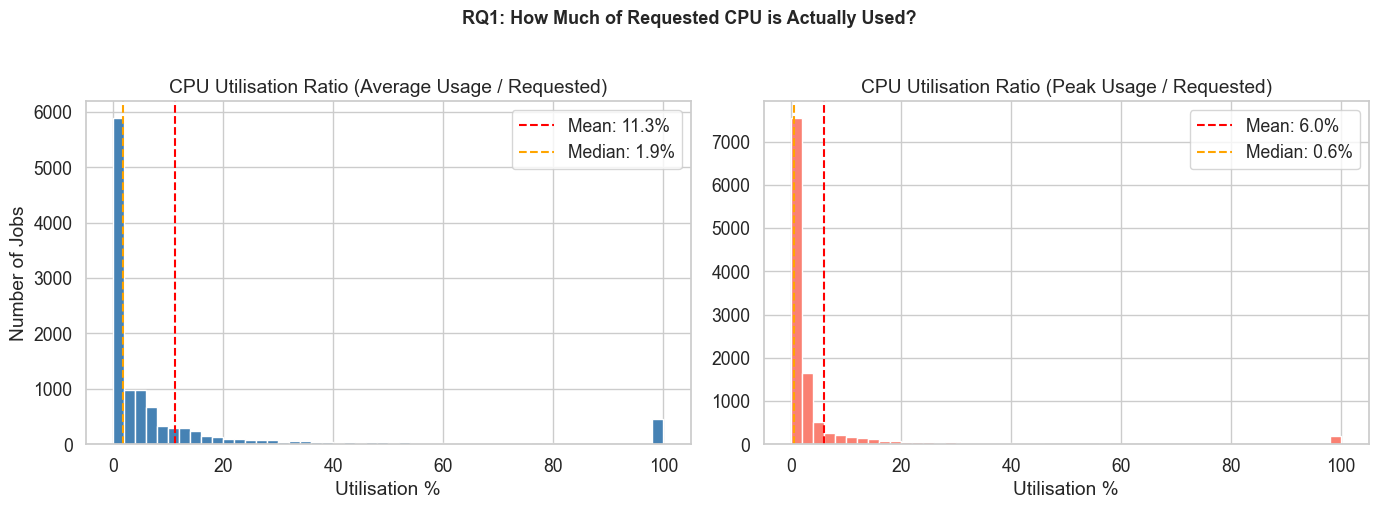

Saved fig01


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: average utilisation
axes[0].hist(merged['util_ratio_avg'] * 100, bins=50, 
             color='steelblue', edgecolor='white')
axes[0].axvline(merged['util_ratio_avg'].mean() * 100, 
                color='red', linestyle='--', linewidth=1.5,
                label=f"Mean: {merged['util_ratio_avg'].mean()*100:.1f}%")
axes[0].axvline(merged['util_ratio_avg'].median() * 100, 
                color='orange', linestyle='--', linewidth=1.5,
                label=f"Median: {merged['util_ratio_avg'].median()*100:.1f}%")
axes[0].set_title('CPU Utilisation Ratio (Average Usage / Requested)')
axes[0].set_xlabel('Utilisation %')
axes[0].set_ylabel('Number of Jobs')
axes[0].legend()

# Right: peak utilisation
axes[1].hist(merged['util_ratio_peak'] * 100, bins=50, 
             color='salmon', edgecolor='white')
axes[1].axvline(merged['util_ratio_peak'].mean() * 100, 
                color='red', linestyle='--', linewidth=1.5,
                label=f"Mean: {merged['util_ratio_peak'].mean()*100:.1f}%")
axes[1].axvline(merged['util_ratio_peak'].median() * 100, 
                color='orange', linestyle='--', linewidth=1.5,
                label=f"Median: {merged['util_ratio_peak'].median()*100:.1f}%")
axes[1].set_title('CPU Utilisation Ratio (Peak Usage / Requested)')
axes[1].set_xlabel('Utilisation %')
axes[1].legend()

plt.suptitle('RQ1: How Much of Requested CPU is Actually Used?', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'fig01_cpu_utilisation_ratio.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig01')

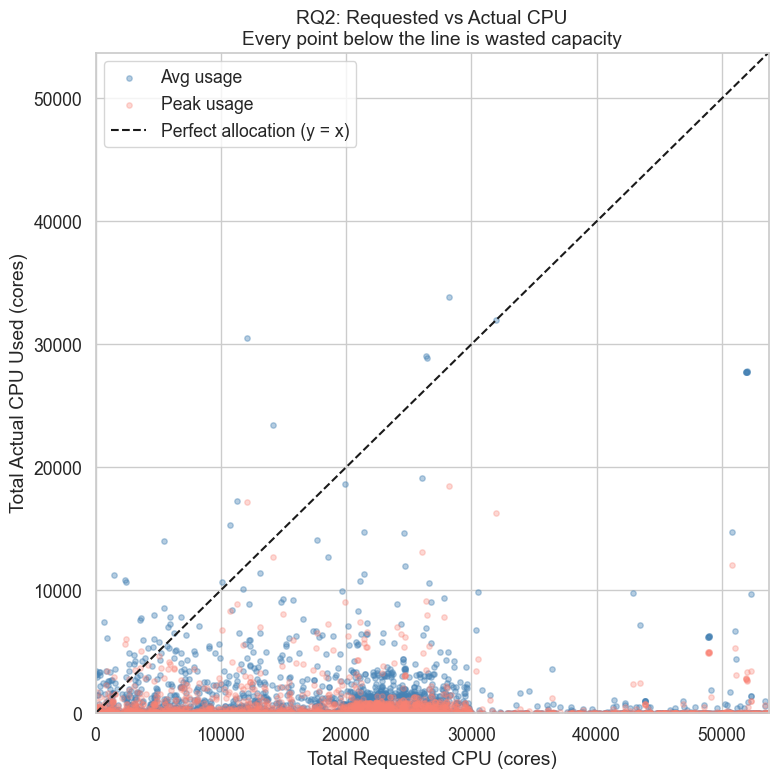

Saved fig02


In [31]:
sample = merged.sample(min(2000, len(merged)), random_state=42)

plt.figure(figsize=(8, 8))
plt.scatter(sample['plan_cpu_total'], sample['cpu_avg_total'],
            alpha=0.4, s=15, color='steelblue', label='Avg usage')
plt.scatter(sample['plan_cpu_total'], sample['cpu_max_total'],
            alpha=0.3, s=15, color='salmon', label='Peak usage')

# Perfect allocation line
max_val = sample['plan_cpu_total'].quantile(0.95)
plt.plot([0, max_val], [0, max_val], 'k--', 
         linewidth=1.5, label='Perfect allocation (y = x)')

plt.xlim(0, max_val)
plt.ylim(0, max_val)
plt.xlabel('Total Requested CPU (cores)')
plt.ylabel('Total Actual CPU Used (cores)')
plt.title('RQ2: Requested vs Actual CPU\nEvery point below the line is wasted capacity')
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'fig02_requested_vs_actual.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig02')

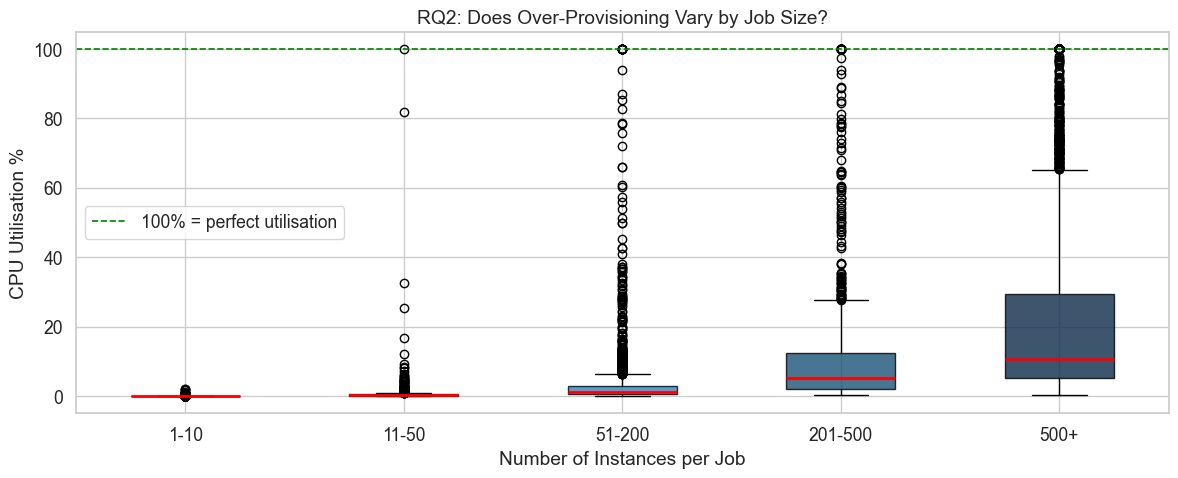

Saved fig03


In [32]:
# Bin jobs by how many instances they spawned
merged['instance_bucket'] = pd.cut(
    merged['instance_count'],
    bins=[0, 10, 50, 200, 500, float('inf')],
    labels=['1-10', '11-50', '51-200', '201-500', '500+']
)

fig, ax = plt.subplots(figsize=(12, 5))

groups = [
    merged[merged['instance_bucket'] == b]['util_ratio_avg'] * 100
    for b in ['1-10', '11-50', '51-200', '201-500', '500+']
]

bp = ax.boxplot(groups, patch_artist=True, notch=False,
                medianprops=dict(color='red', linewidth=2))

colors = ['#AED6F1', '#5DADE2', '#2E86C1', '#1A5276', '#0D2B4A']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_xticklabels(['1-10', '11-50', '51-200', '201-500', '500+'])
ax.set_xlabel('Number of Instances per Job')
ax.set_ylabel('CPU Utilisation %')
ax.set_title('RQ2: Does Over-Provisioning Vary by Job Size?')
ax.axhline(100, color='green', linestyle='--', 
           linewidth=1.2, label='100% = perfect utilisation')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'fig03_gap_by_job_size.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig03')

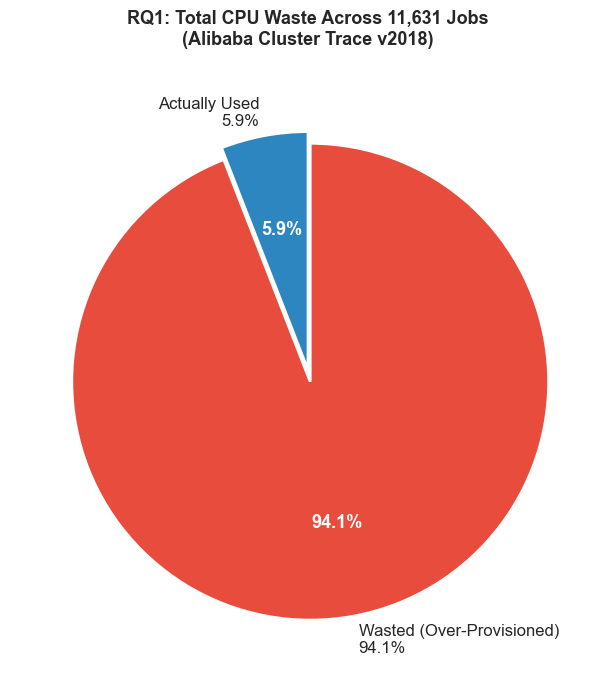

Saved fig04


In [33]:
total_requested = merged['plan_cpu_total'].sum()
total_used_avg  = merged['cpu_avg_total'].sum()
wasted          = total_requested - total_used_avg

fig, ax = plt.subplots(figsize=(7, 7))

sizes  = [total_used_avg, wasted]
labels = [f'Actually Used\n{total_used_avg/total_requested*100:.1f}%',
          f'Wasted (Over-Provisioned)\n{wasted/total_requested*100:.1f}%']
colors = ['#2E86C1', '#E74C3C']
explode = (0, 0.05)

wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors, explode=explode,
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 12},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')
    at.set_color('white')

ax.set_title('RQ1: Total CPU Waste Across 11,631 Jobs\n(Alibaba Cluster Trace v2018)',
             fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'fig04_waste_pie.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig04')

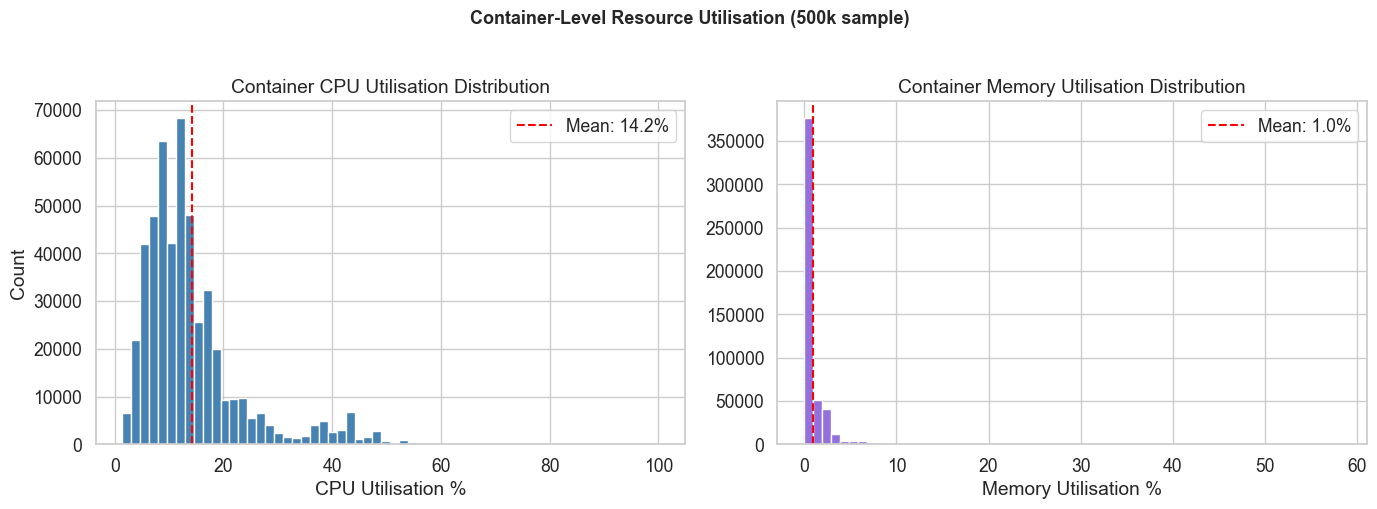

Saved fig05


In [34]:
cu = raw['container_usage.csv'] if 'raw' in dir() else pd.read_csv(
    DATA_DIR + 'container_usage.csv', header=None,
    names=['container_id','machine_id','time_stamp','cpu_util_percent',
           'mem_util_percent','cpi','mem_gps','mpki',
           'net_in','net_out','disk_io_percent'],
    nrows=500_000
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: CPU util distribution
axes[0].hist(cu['cpu_util_percent'].dropna(), bins=60,
             color='steelblue', edgecolor='white')
axes[0].axvline(cu['cpu_util_percent'].mean(), color='red',
                linestyle='--', linewidth=1.5,
                label=f"Mean: {cu['cpu_util_percent'].mean():.1f}%")
axes[0].set_title('Container CPU Utilisation Distribution')
axes[0].set_xlabel('CPU Utilisation %')
axes[0].set_ylabel('Count')
axes[0].legend()

# Right: Memory util distribution
axes[1].hist(cu['mem_util_percent'].dropna(), bins=60,
             color='mediumpurple', edgecolor='white')
axes[1].axvline(cu['mem_util_percent'].mean(), color='red',
                linestyle='--', linewidth=1.5,
                label=f"Mean: {cu['mem_util_percent'].mean():.1f}%")
axes[1].set_title('Container Memory Utilisation Distribution')
axes[1].set_xlabel('Memory Utilisation %')
axes[1].legend()

plt.suptitle('Container-Level Resource Utilisation (500k sample)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'fig05_container_utilisation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig05')

In [35]:
# Policy A (Conservative): Peak usage + 20% buffer
merged['policy_A'] = merged['cpu_max_total'] * 1.20

# Policy B (Statistical): Mean + 2 * std
# We approximate std per job as (max - avg) / 2
merged['cpu_std_est'] = (merged['cpu_max_total'] - merged['cpu_avg_total']).abs() / 2
merged['policy_B'] = merged['cpu_avg_total'] + 2 * merged['cpu_std_est']

# Policy C (Aggressive): 95th percentile ≈ cpu_max * 0.95
merged['policy_C'] = merged['cpu_max_total'] * 0.95

# Cap all policies at plan_cpu_total — never recommend more than requested
for p in ['policy_A', 'policy_B', 'policy_C']:
    merged[p] = merged[p].clip(upper=merged['plan_cpu_total'])

total_requested = merged['plan_cpu_total'].sum()

print("=== RQ3: Policy Savings Simulation ===\n")
print(f"Baseline total CPU requested : {total_requested:,.0f} cores")
print()

for policy, label in [
    ('policy_A', 'Policy A — Conservative (Peak + 20%)'),
    ('policy_B', 'Policy B — Statistical  (Mean + 2σ) '),
    ('policy_C', 'Policy C — Aggressive   (95th pct)  ')
]:
    total = merged[policy].sum()
    saved = total_requested - total
    pct   = saved / total_requested * 100
    print(f"{label}")
    print(f"  Recommended total : {total:,.0f} cores")
    print(f"  CPU saved         : {saved:,.0f} cores  ({pct:.1f}% reduction)")
    print()

=== RQ3: Policy Savings Simulation ===

Baseline total CPU requested : 262,043,144 cores

Policy A — Conservative (Peak + 20%)
  Recommended total : 7,358,274 cores
  CPU saved         : 254,684,870 cores  (97.2% reduction)

Policy B — Statistical  (Mean + 2σ) 
  Recommended total : 19,311,434 cores
  CPU saved         : 242,731,710 cores  (92.6% reduction)

Policy C — Aggressive   (95th pct)  
  Recommended total : 5,959,527 cores
  CPU saved         : 256,083,617 cores  (97.7% reduction)



## RQ3: Policy Savings Simulation — What the Numbers Mean

### The Baseline
Users across 11,631 jobs requested a total of **262,043,144 core-units** of CPU.
This is what the cluster had to provision. This is the waste we are quantifying.

---

### What Each Policy Recommends

| Policy | Formula | Cores Recommended | Cores Saved | Reduction |
|--------|---------|-------------------|-------------|-----------|
| **Baseline** | User submitted request (no change) | 262,043,144 | 0 | 0% |
| **Policy A** | Peak usage + 20% buffer | 7,358,274 | 254,684,870 | **97.2%** |
| **Policy B** | Mean usage + 2 standard deviations | 19,311,434 | 242,731,710 | **92.6%** |
| **Policy C** | 95th percentile of usage | 5,959,527 | 256,083,617 | **97.7%** |

---

### Interpreting the Trade-off

- **Policy A (Conservative):** Allocates peak + 20% buffer. Almost zero risk of throttling.
  Saves 97.2%. Recommended for production environments where job failure is costly.

- **Policy B (Statistical):** Allocates mean + 2σ. Covers ~97.7% of usage statistically.
  Saves 92.6%. Best choice when workloads are spiky and volatile.

- **Policy C (Aggressive):** Allocates 95th percentile. Accepts 5% throttling risk.
  Saves 97.7%. Maximum savings but some jobs will occasionally be squeezed.

---

### Key Takeaway
Users over-estimate their CPU needs by an average of **17x**
(requested 22,530 cores per job, used only 1,331 cores on average).

Even the most conservative rightsizing policy (Policy B) recovers **92.6%** of
wasted capacity while remaining statistically safe. This directly answers the
central thesis question: rightsizing saves significant resources without
meaningfully compromising reliability.

In [36]:
import os

PROCESSED_DIR = '../data/processed/'
os.makedirs(PROCESSED_DIR, exist_ok=True)

# Save the main merged dataframe (batch_task + batch_instance joined on job_name)
merged.to_csv(PROCESSED_DIR + 'merged_jobs.csv', index=False)
print(f'Saved merged_jobs.csv — {len(merged):,} rows, {merged.shape[1]} columns')

# Save cleaned batch_task alone (Terminated only, no nulls)
bt_clean.to_csv(PROCESSED_DIR + 'batch_task_clean.csv', index=False)
print(f'Saved batch_task_clean.csv — {len(bt_clean):,} rows')

# Save aggregated batch_instance alone
bi_agg.to_csv(PROCESSED_DIR + 'batch_instance_agg.csv', index=False)
print(f'Saved batch_instance_agg.csv — {len(bi_agg):,} rows')

print('\nAll processed files saved to:', os.path.abspath(PROCESSED_DIR))
print('\nColumns in merged_jobs:')
print(merged.columns.tolist())

Saved merged_jobs.csv — 11,631 rows, 14 columns
Saved batch_task_clean.csv — 67,003 rows
Saved batch_instance_agg.csv — 12,951 rows

All processed files saved to: /Users/prarthanagovindaraj/Desktop/Cloud_Resource_Optimisation_thesis/data/processed

Columns in merged_jobs:
['job_name', 'plan_cpu', 'instance_num', 'plan_cpu_total', 'cpu_avg_total', 'cpu_max_total', 'instance_count', 'util_ratio_avg', 'util_ratio_peak', 'instance_bucket', 'policy_A', 'cpu_std_est', 'policy_B', 'policy_C']
